In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/project-lab')
ORIGINAL_PATH = PROJECT_ROOT / 'data' / 'meas_gre_dir1.mat'

assert ORIGINAL_PATH.exists(), f'원본 파일을 찾을 수 없습니다: {ORIGINAL_PATH}'
print('원본 데이터: ', ORIGINAL_PATH)

원본 데이터:  /content/drive/MyDrive/project-lab/data/meas_gre_dir1.mat


In [5]:
from scipy.io import whosmat

# 변수 목록 확인
print('MAT 파일 변수 목록')
for name, shape, dtype in whosmat(ORIGINAL_PATH):
  print(f"{name}: shape={shape}, type={dtype}")

MAT 파일 변수 목록
B0_dir: shape=(1, 3), type=double
CF: shape=(1, 1), type=double
delta_TE: shape=(1, 1), type=double
mask_brain: shape=(256, 224, 176), type=double
meas_gre: shape=(256, 224, 176, 6), type=double
te_gre: shape=(6, 1), type=double
tolvalue: shape=(1, 1), type=double
voxel_size_gre: shape=(3, 1), type=double


In [6]:
# 필요한 데이터 불러오기
import numpy as np
from scipy.io import loadmat

mat = loadmat(
    ORIGINAL_PATH,
    variable_names=["meas_gre", "mask_brain", "te_gre"],
)

image = mat["meas_gre"]
mask = mat["mask_brain"].astype(bool)
echo_times = mat["te_gre"].ravel()

assert image.ndim == 4, f'4D 데이터가 아닙니다: {image.shape}'
assert np.iscomplexobj(image), f'complex 데이터가 아닙니다: {image.dtype}'
assert mask.shape == image.shape[:3], (mask.shape, image.shape)

print('MRI 크기: ', image.shape)
print('MRI 자료형: ', image.dtype)
print('Complex 데이터 여부: ', np.iscomplexobj(image))
print('마스크 크기: ', mask.shape)
print('에코 시간: ', echo_times)

MRI 크기:  (256, 224, 176, 6)
MRI 자료형:  complex128
Complex 데이터 여부:  True
마스크 크기:  (256, 224, 176)
에코 시간:  [0.0077  0.01273 0.01776 0.02279 0.02782 0.03285]


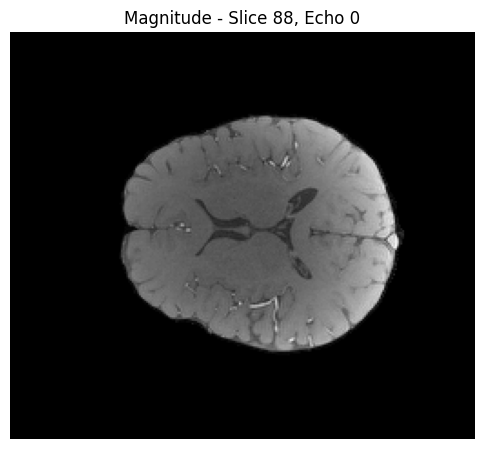

In [7]:
# MRI 한 장 확인하기
import matplotlib.pyplot as plt

slice_index = 88
echo_index = 0

signal = image[:, :, slice_index, echo_index]
magnitude = np.abs(signal)

plt.figure(figsize=(6, 6))
plt.imshow(magnitude.T, cmap="gray", origin="lower")
plt.title(f"Magnitude - Slice {slice_index}, Echo {echo_index}")
plt.axis("off")
plt.show()

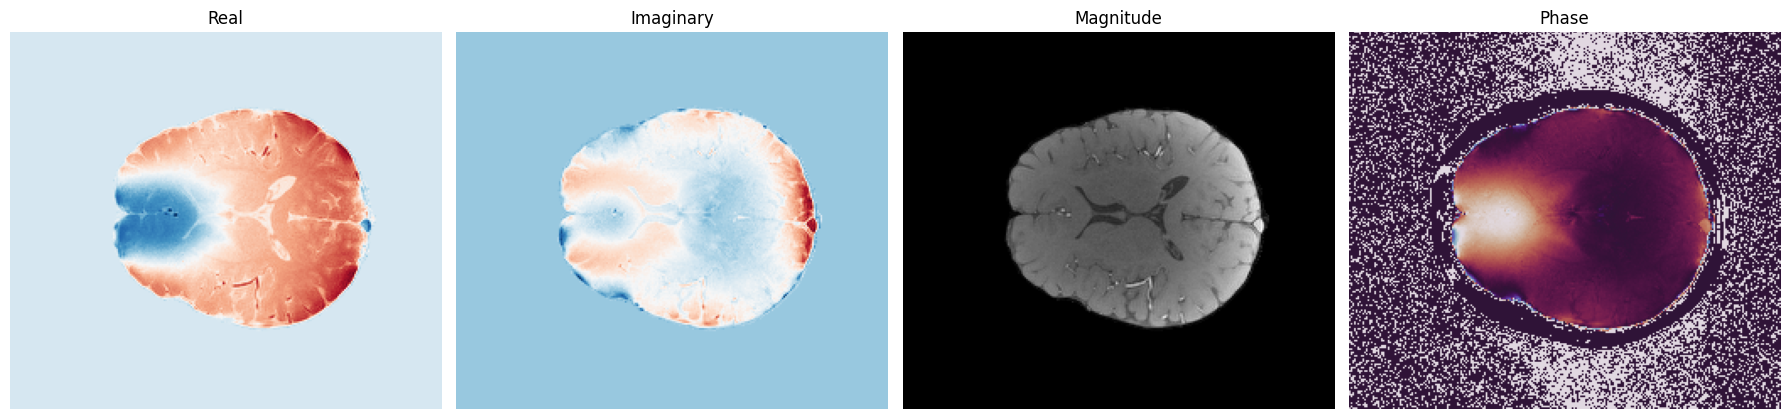

In [8]:
# Real·Imaginary·Magnitude·Phase 한 번에 보기
signal = image[:, :, slice_index, echo_index]

real = signal.real
imaginary = signal.imag
magnitude = np.abs(signal)
phase = np.angle(signal)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

panels = [
    (real, "Real", "RdBu_r"),
    (imaginary, "Imaginary", "RdBu_r"),
    (magnitude, "Magnitude", "gray"),
    (phase, "Phase", "twilight"),
]

for ax, (data, title, cmap) in zip(axes, panels):
  ax.imshow(data.T, cmap=cmap, origin="lower")
  ax.set_title(title)
  ax.axis("off")

plt.tight_layout()
plt.show()

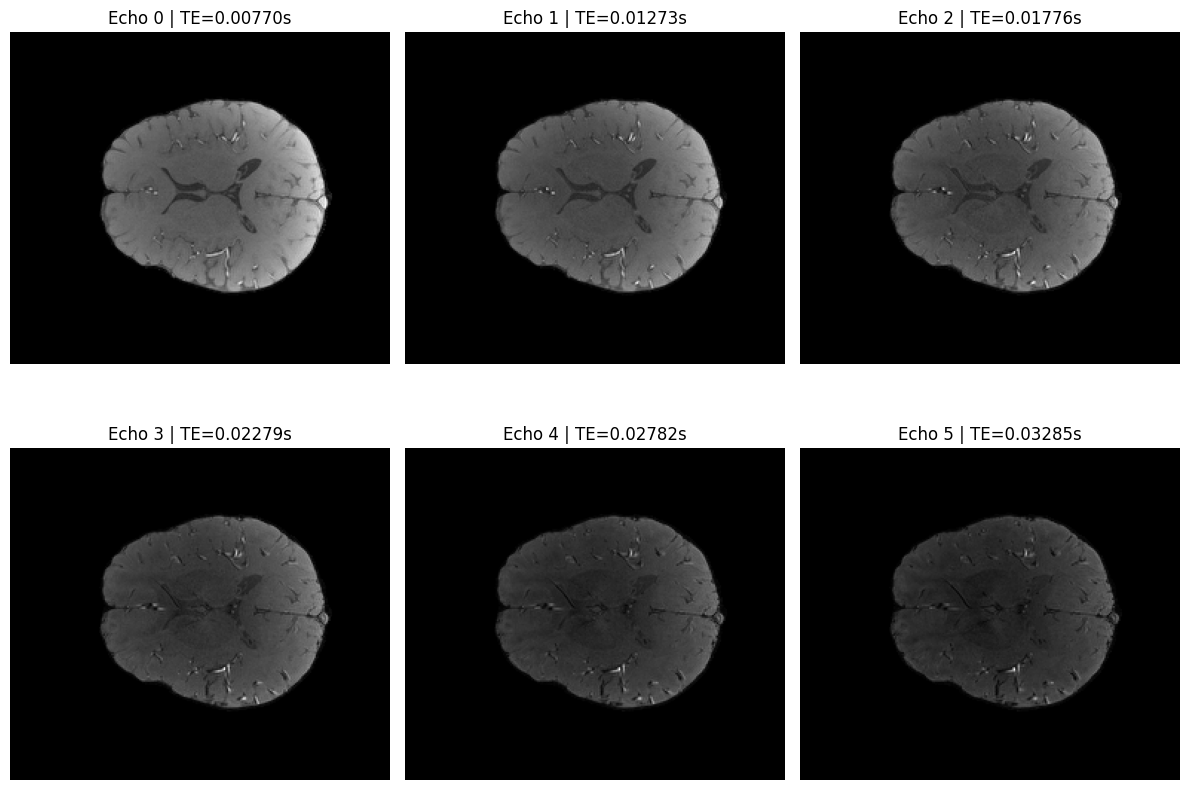

In [9]:
# 에코 6개 비교하기
fig, axes = plt.subplots(2, 3, figsize=(12, 9))

for echo_index, ax in enumerate(axes.flat):
  magnitude = np.abs(image[:, :, slice_index, echo_index])

  ax.imshow(magnitude.T, cmap="gray", origin="lower")
  ax.set_title(f"Echo {echo_index} | TE={echo_times[echo_index]:.5f}s")
  ax.axis("off")

plt.tight_layout()
plt.show()